# Создание модели предсказания стоимости подержанных автомобилей с учётом бизнес-рисков

**Описание исследования**

Необходимо разработать модель автоматической оценки рыночной стоимости подержанных автомобилей для сервиса мгновенного выкупа AutoValue AI. Модель должна за доли секунды рассчитывать справедливую цену на основе характеристик автомобиля и региональной специфики рынка - это позволит компании масштабироваться до 10 000 заявок в день и устранить человеческий фактор. Задача регрессии - предсказать рыночную стоимость автомобиля в рублях.

---

**Цель исследования**

Разработать и обучить модель регрессии для прогнозирования рыночной стоимости подержанного автомобиля, а также провести сравнительный турнир трёх библиотек градиентного бустинга (LightGBM, CatBoost, XGBoost) для выбора основного инструмента компании.

- **Тип задачи:** Регрессия.
- **Целевая переменная:** Рыночная стоимость автомобиля в рублях (`price_rub`).
- **Ключевой вызов:** Баланс между переплатой и занижением цены - ошибка в любую сторону несёт прямые финансовые потери.
- **Бизнес-метрики:**
    - **Overpricing Rate:** Доля случаев, когда модель завысила цену более чем на 20%. Риск купить неликвид и уйти в убыток.
    - **Underpricing Loss:** Суммарная упущенная выгода по случаям занижения цены более чем на 20%. Клиент уходит к конкурентам.

---

**Задачи исследования**

- **Анализ и подготовка данных:** Обработка пропусков, кодирование категориальных признаков и выявление ценовых выбросов.
- **EDA:** Исследование ключевых факторов стоимости - амортизация по году выпуска, влияние пробега, эффект числа владельцев, региональная дифференциация цен.
- **Турнир библиотек:** Обучение LightGBM, CatBoost и XGBoost в идентичных условиях с подбором гиперпараметров и сравнением по единым метрикам.
- **Валидация и интерпретация:** Финальная проверка лучшей модели на отложенной выборке, анализ важности признаков и выявление сегментов с систематическим завышением цены.

---

**Описание данных**

Два файла, имитирующих реальный производственный цикл: обучение на исторических сделках и финальная проверка на новой партии автомобилей.

- `ds_s16_train_data.csv` 
    - история 8 000 сделок, проведённых экспертами компании. Основа для обучения и подбора гиперпараметров.
- `ds_s16_test_data.csv` 
    - 2 000 записей исключительно для финальной оценки. **Использование на этапе обучения категорически запрещено.**

| Признак | Описание |
|---|---|
| `brand` | Марка автомобиля |
| `make_year` | Год выпуска |
| `mileage_kmpl` | Пробег (км) |
| `engine_cc` | Объём двигателя (куб. см) |
| `fuel_type` | Тип топлива |
| `transmission` | Тип коробки передач |
| `owner_count` | Количество владельцев по ПТС |
| `color` | Цвет автомобиля |
| `service_history` | Наличие сервисной книжки |
| `accidents_reported` | Количество зафиксированных ДТП |
| `insurance_valid` | Действительна ли страховка |
| `region` | Макрорегион РФ |
| `price_rub` | **Целевой признак:** рыночная стоимость в рублях |

## Загрузка необходимых библиотек

In [58]:
from pathlib import Path

req_path = Path("../../requirements.txt")
if req_path.exists():
    %pip install -qr {req_path}
else:
    %pip install -qU "numpy<2.2.0" "pandas==2.2.2" numba scipy scikit-learn matplotlib seaborn phik joblib category_encoders optuna plotly nbformat jinja2 catboost xgboost lightgbm shap

In [59]:
import joblib
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

import sklearn
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from shap import force_plot, summary_plot, TreeExplainer, LinearExplainer, sample

from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [60]:
RANDOM_STATE = 42

## EDA (Экспресс-анализ данных)

In [61]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive монтирован")
except ImportError:
    print("Локальное использование")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive монтирован


In [62]:
def get_df(file_name):
    drive_path = Path(f'/content/drive/MyDrive/datasets/{file_name}')
    yp_path = Path(f'/datasets/{file_name}')

    if drive_path.exists():
        df = pd.read_csv(drive_path, sep=',', decimal='.')
    elif yp_path.exists():
        df = pd.read_csv(yp_path, sep=',', decimal='.')
    else:
        raise "Путь до датасета неверный"

    int_cols = df.select_dtypes(include=['integer']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    float_cols = df.select_dtypes(include=['float']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    print('-' * 70)
    print(file_name)
    display(df.head())
    df.info()

    return df

train_df = get_df('ds_s16_train_data.csv')
test_df = get_df('ds_s16_test_data.csv')

----------------------------------------------------------------------
ds_s16_train_data.csv


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int16  
 1   mileage_kmpl        8000 non-null   float32
 2   engine_cc           8000 non-null   int16  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int8   
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int8   
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int32  
 12  region              8000 non-null   object 
dtypes: float32(1), int16(2), int32(1), int8(2), object(7)
memory usage: 547.0+ KB
----------------------------------------------------------------------
ds_s

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int16  
 1   mileage_kmpl        2000 non-null   float32
 2   engine_cc           2000 non-null   int16  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int8   
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int8   
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int32  
 12  region              2000 non-null   object 
dtypes: float32(1), int16(2), int32(1), int8(2), object(7)
memory usage: 136.8+ KB


In [63]:
print("Явные дубликаты строк:", train_df.duplicated().sum())
train_df = train_df.drop_duplicates(keep='first')

Явные дубликаты строк: 0


In [64]:
num_cols = train_df.select_dtypes(include=['number']).columns
cat_cols = train_df.select_dtypes(include=['object']).columns

In [65]:
eda_df = train_df.copy()

In [66]:
price = eda_df['price_rub']

price.describe()

,price_rub
count,8000.00
mean,683647.87
std,264923.50
min,95000.00
25%,493857.00
50%,663866.00
75%,855056.00
max,1676525.00


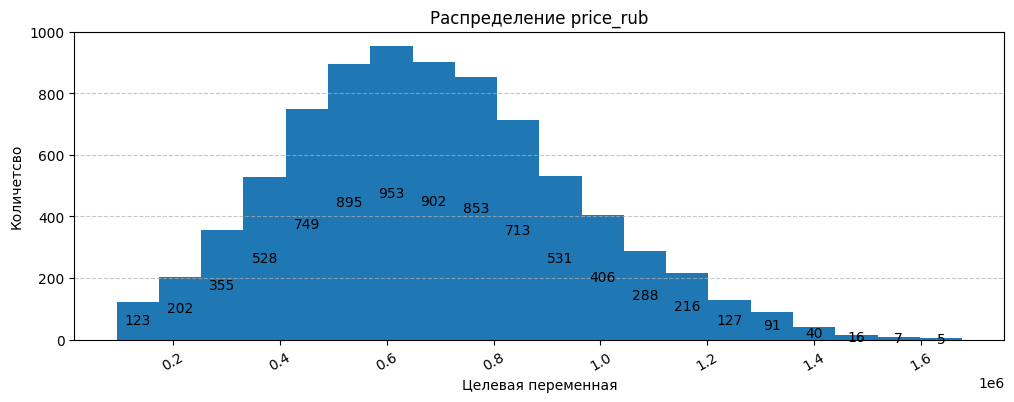

In [67]:
ax = price.plot(
    kind='hist',
    title=f'Распределение {price.name}',
    xlabel='Целевая переменная',
    ylabel='Количетсво',
    rot=30,
    bins=20,
    figsize=(12, 4),
)

ax.bar_label(ax.containers[0], label_type='center')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
plt.close()

Целевая переменная price_rub имеет распределение, близкое к нормальному, с центром около 500–700 тыс. рублей и лёгким правым хвостом - единичные автомобили оцениваются дороже 1.4 млн. Основная масса сделок сосредоточена в диапазоне 400–900 тыс. рублей, что соответствует типичному массовому сегменту подержанных автомобилей. Выраженных аномалий нет, распределение достаточно симметрично, поэтому логарифмирование таргета не потребуется.

In [68]:
def show_features(df, cols):
    table = []

    for col in cols:
        table.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': df[col].nunique(),
        })
    
    display(pd.DataFrame(table).sort_values('Кол-во', ascending=False))

In [69]:
def show_custom_scatter(df, col, name, cus_ax=None):
    ax = sns.scatterplot(
        data=df,
        x=col,
        y='price_rub',
        alpha=0.4,
        s=20,
        edgecolor=None,
        ax=cus_ax
    )
    
    if not cus_ax:
        cus_ax = ax

    cus_ax.set_title(f'Зависимость цены от {name}', fontsize=14, fontweight='bold')
    cus_ax.set_xlabel('Значение признака')
    cus_ax.set_ylabel('Цена (руб.)')
    cus_ax.grid(True)

In [70]:
def create_num_plot(df, col):
    cur_series = df[col]
    
    _, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))
    
    hist = axes[0]
    cur_series.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    hist.set_title(f'Распределение: {cur_series.name}', fontsize=12)
    hist.set_xlabel('Значение')
    hist.set_ylabel('Количество (log)')
    hist.set_yscale('log')
    
    box = axes[1]
    sns.boxplot(
        data=cur_series,
        ax=box
    )
    box.set_title(f'Размах: {cur_series.name}', fontsize=12)
    box.set_ylabel('Значение')
    box.grid(True)
    box.tick_params(axis='x', rotation=30)

    scatter = axes[2]
    show_custom_scatter(df, col, cur_series.name, scatter)

    plt.tight_layout()
    plt.show()
    plt.close()
    
def show_num_plots(df, cols):
    for col in cols:
        create_num_plot(df, col)

In [71]:
def create_cat_plot(series):
    plt.figure(figsize=(12, 4))
    
    ax = sns.countplot(
        x=series,
        hue=series,
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)
        
    plt.tight_layout()
    plt.show()
    plt.close()
    
def show_cat_plots(df, cols):
    for col in cols:
        create_cat_plot(df[col])

Анализ числовых признаков

In [72]:
show_features(eda_df, num_cols)

,Признак,Уникальные значения,Кол-во
5,price_rub,"[242073, 426029, 727050, 753168, 733390, 97099...",7929
1,mileage_kmpl,"[9.7, 16.1, 10.51, 14.27, 21.72, 18.22, 19.19,...",2108
0,make_year,"[2002, 2004, 2005, 2019, 2015, 2011, 1995, 201...",29
2,engine_cc,"[1800, 1500, 5000, 2000, 1000, 3000, 800, 2500...",10
4,accidents_reported,"[0, 1, 2, 3, 4, 5]",6
3,owner_count,"[2, 3, 5, 1, 4]",5


In [73]:
new_cat_cols = ['accidents_reported', 'owner_count']

upd_cat_cols = cat_cols.to_list() + new_cat_cols
upd_num_cols = [col for col in num_cols.to_list() if col not in new_cat_cols + ['price_rub']]

In [74]:
show_features(eda_df, upd_num_cols)

,Признак,Уникальные значения,Кол-во
1,mileage_kmpl,"[9.7, 16.1, 10.51, 14.27, 21.72, 18.22, 19.19,...",2108
0,make_year,"[2002, 2004, 2005, 2019, 2015, 2011, 1995, 201...",29
2,engine_cc,"[1800, 1500, 5000, 2000, 1000, 3000, 800, 2500...",10


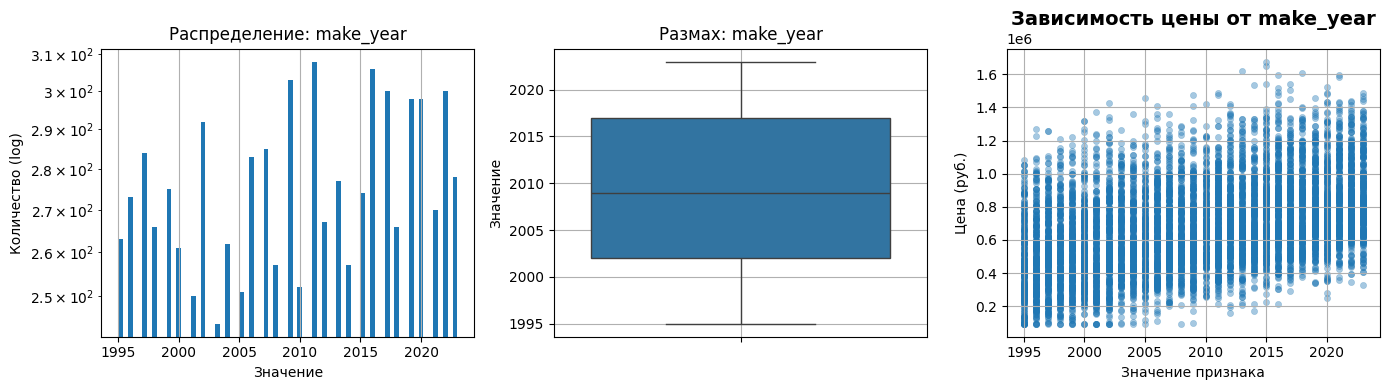

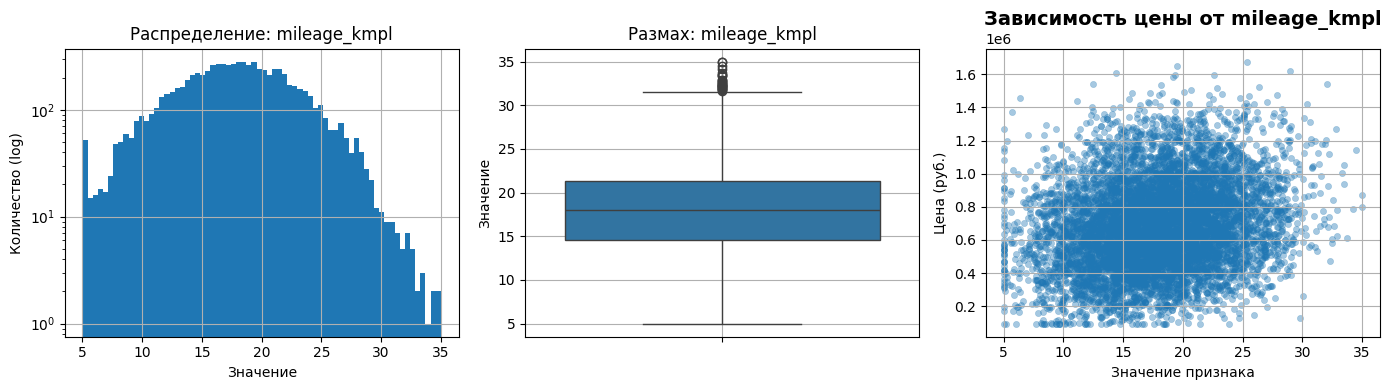

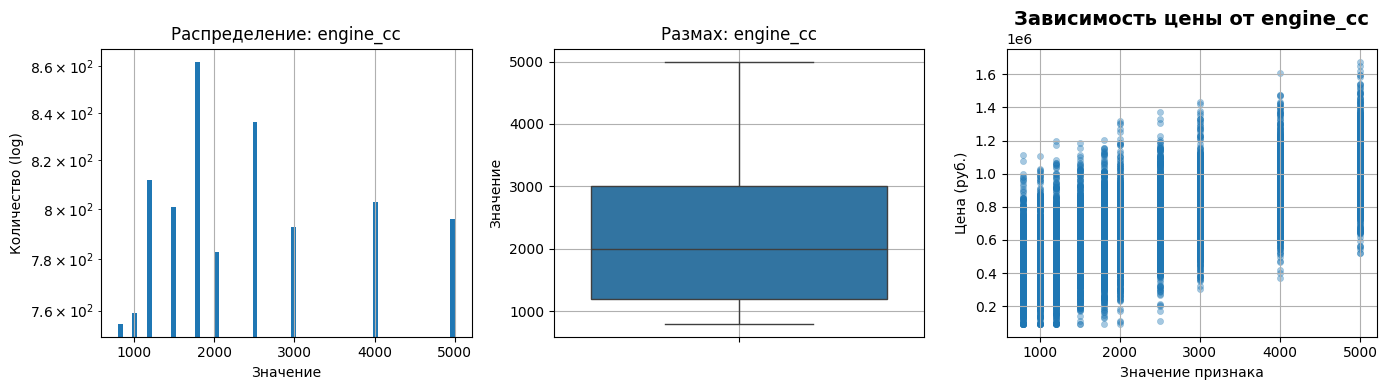

In [75]:
show_num_plots(eda_df, upd_num_cols)

Анализ категориальных признаков

In [76]:
show_features(eda_df, upd_cat_cols)

,Признак,Уникальные значения,Кол-во
1,brand,"[Hyundai, Ford, Toyota, Nissan, Kia, Tesla, BM...",10
7,accidents_reported,"[0, 1, 2, 3, 4, 5]",6
3,color,"[Silver, Black, Gray, White, Blue, Red]",6
6,region,"[Урал, Москва, Юг, Дальний Восток, Сибирь, СПб]",6
8,owner_count,"[2, 3, 5, 1, 4]",5
0,fuel_type,"[Diesel, Petrol, Electric]",3
4,service_history,"[Partial, Unknown, Full]",3
2,transmission,"[Manual, Automatic]",2
5,insurance_valid,"[No, Yes]",2


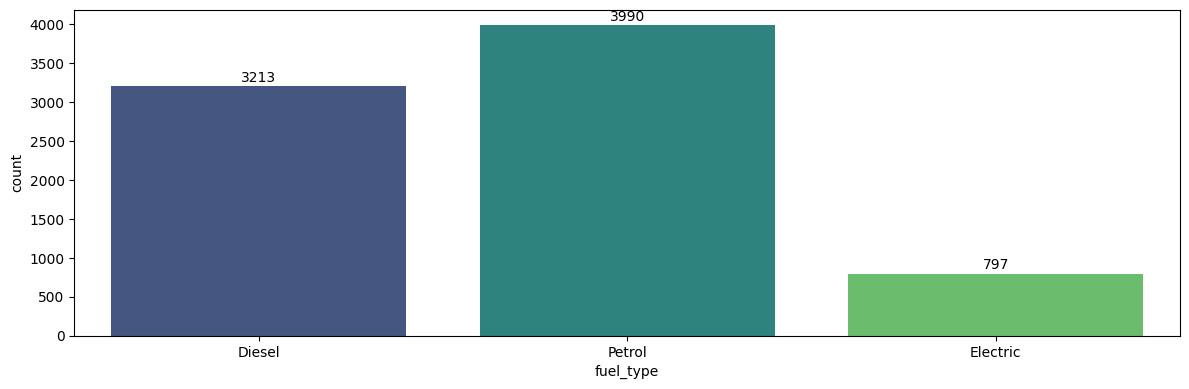

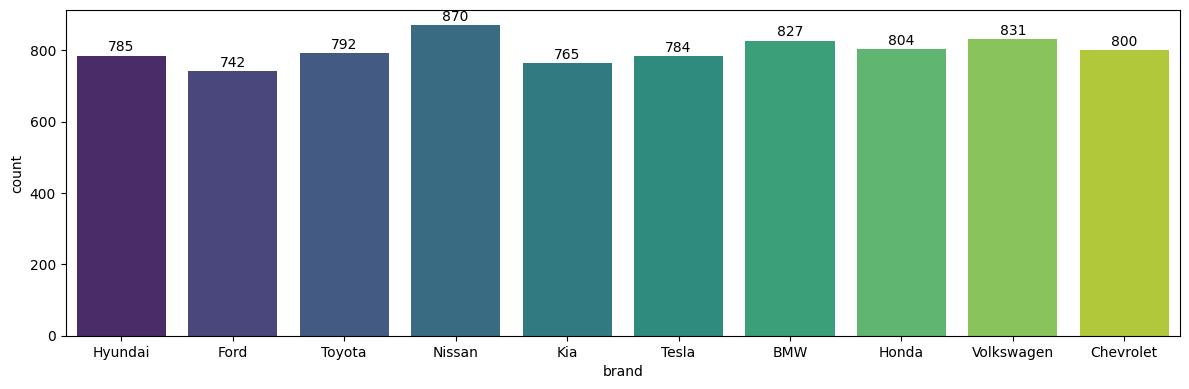

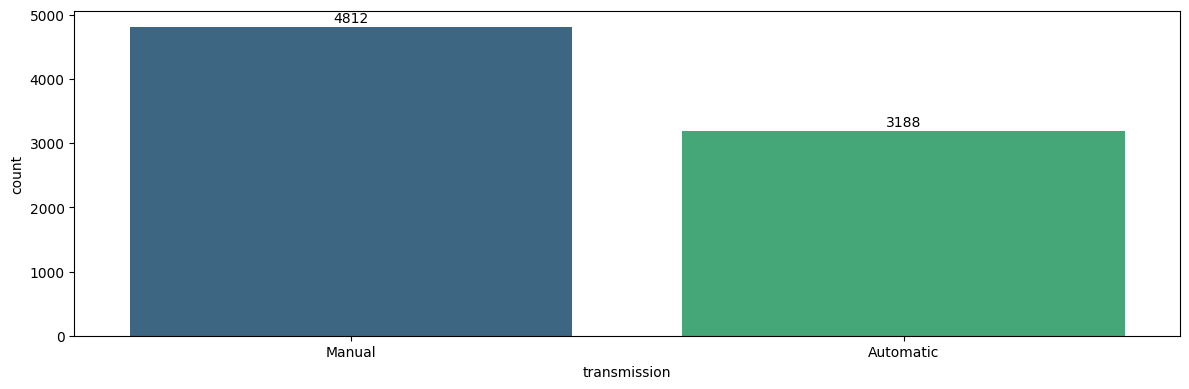

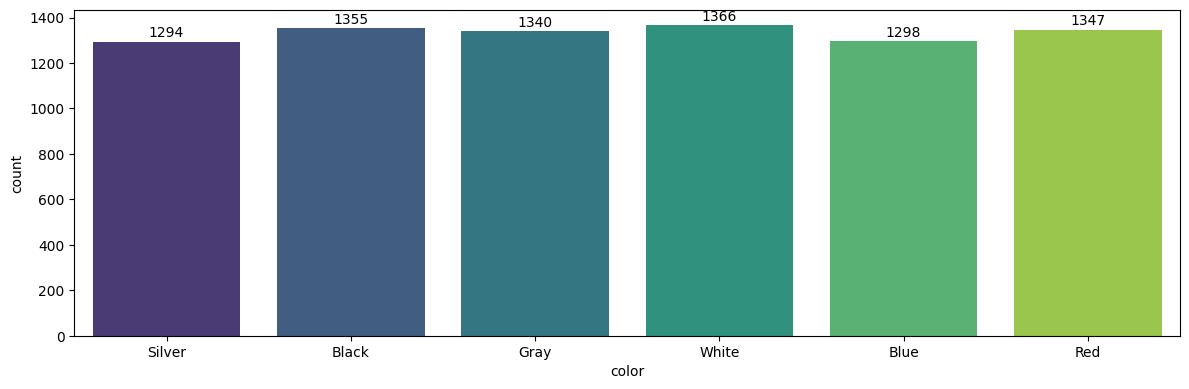

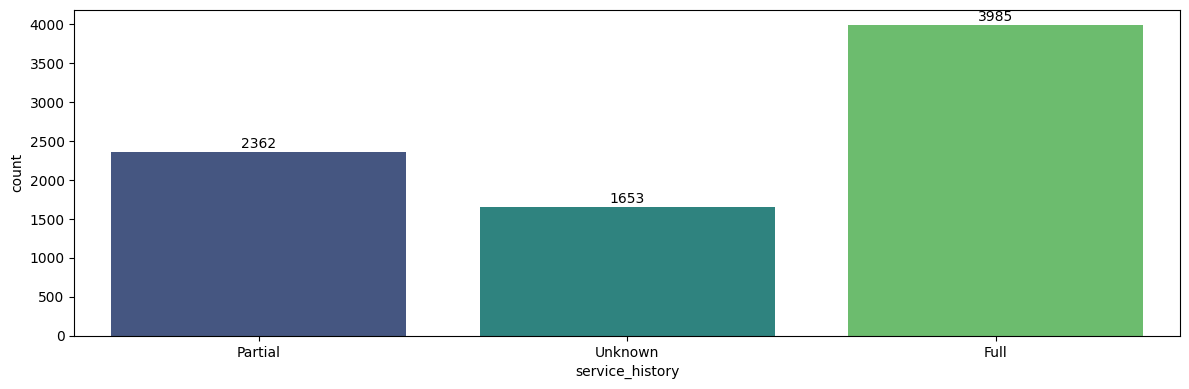

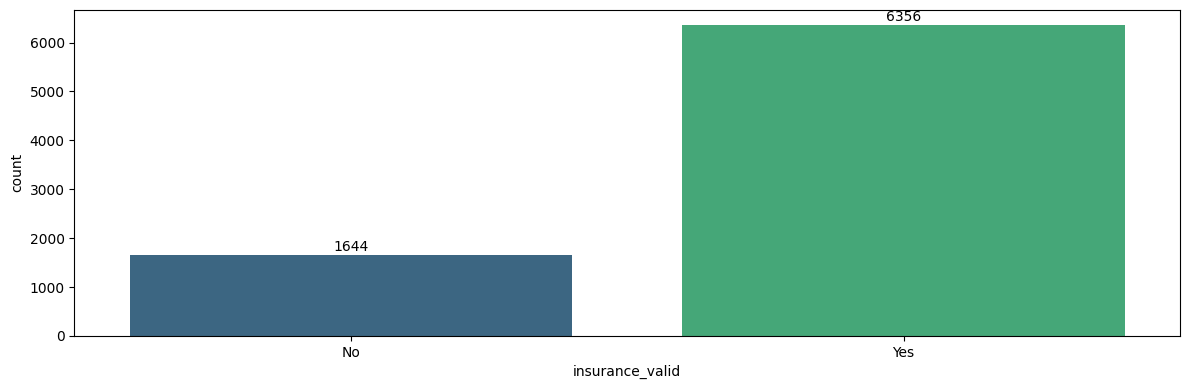

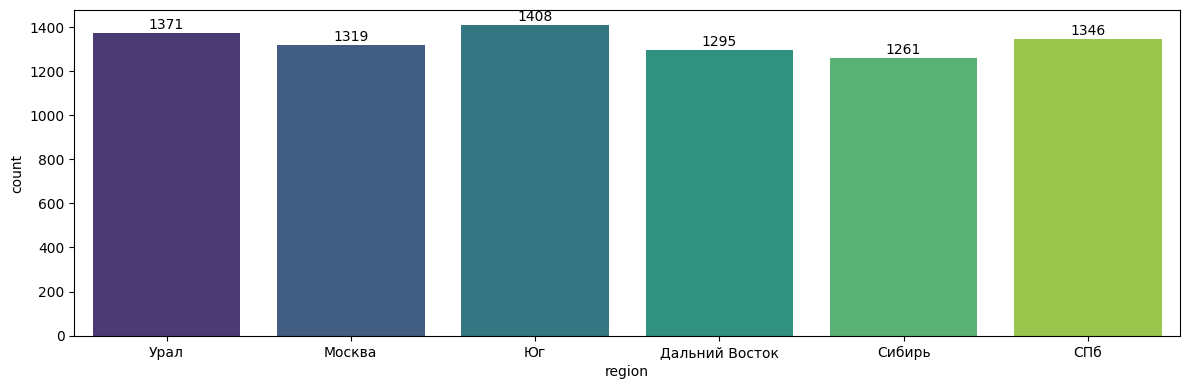

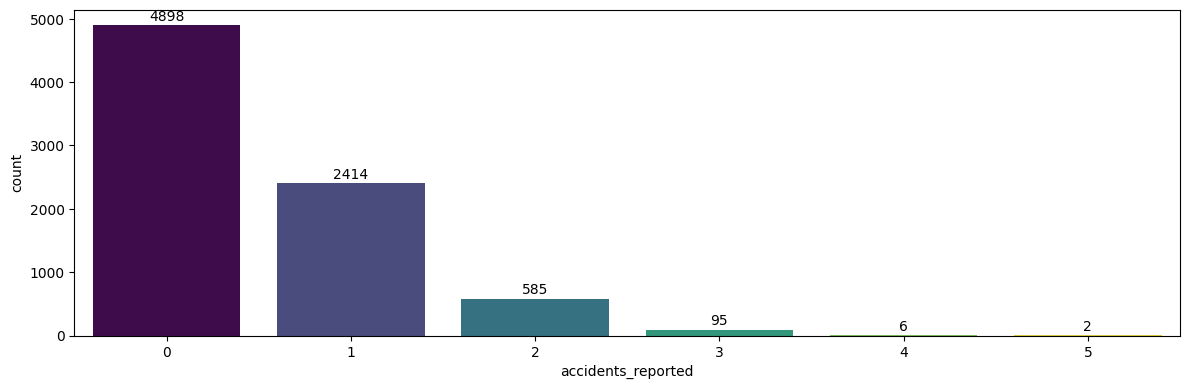

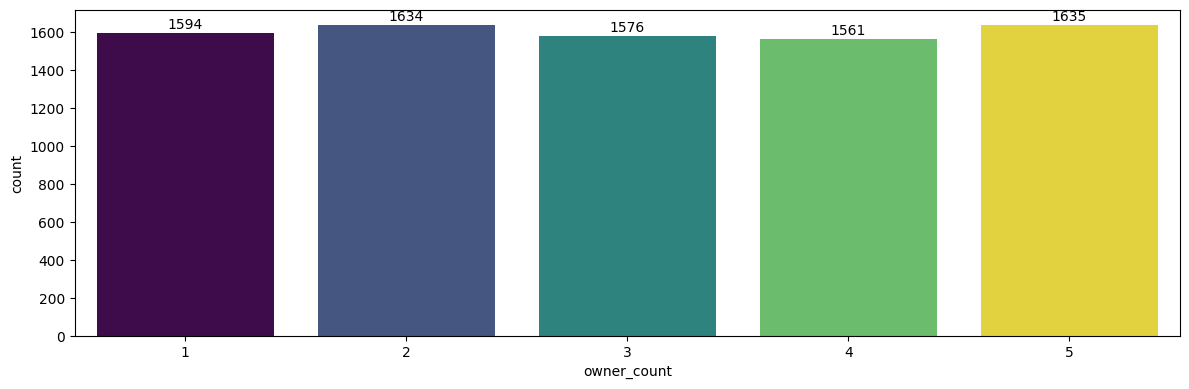

In [77]:
show_cat_plots(eda_df, upd_cat_cols)

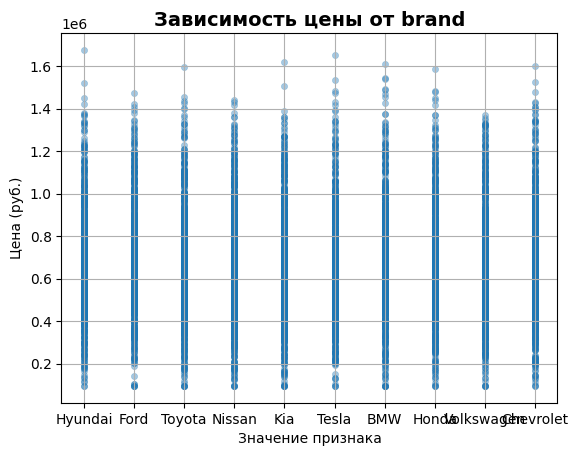

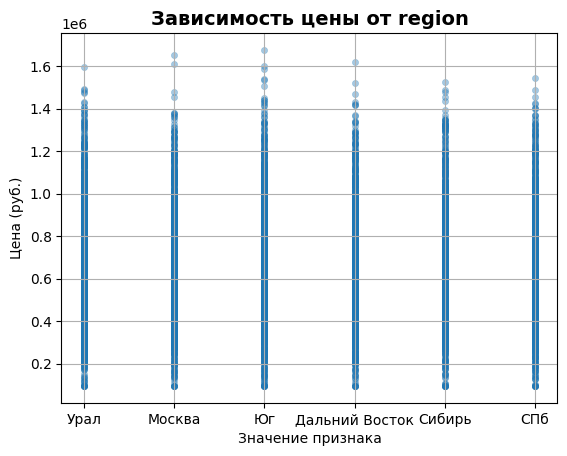

In [78]:
for col in ['brand', 'region']:
    show_custom_scatter(eda_df, col, col)
    plt.show()
    plt.close()

По обоим графикам вывод одинаковый: ни марка автомобиля, ни регион не оказывают заметного влияния на цену - распределение стоимости у всех категорий практически идентично и покрывает весь диапазон от 100 тыс. до 1.6 млн рублей. Это подтверждает низкую корреляцию этих признаков с таргетом, которую мы наблюдали в матрице корреляций, и объясняет почему модель опирается на технические характеристики, а не на бренд или географию.

Анализ корреляций

In [79]:
def show_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef)
    plt.figure(figsize=(x, dynamic_height))
    
    sns.heatmap(
        corr, 
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False,
    )

    plt.title(title)
    plt.show()

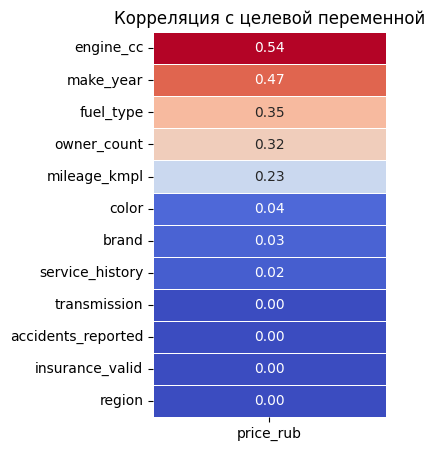

In [80]:
corr_matrix = eda_df.phik_matrix(interval_cols=['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported', 'price_rub'])
target_corr = corr_matrix[corr_matrix.index != 'price_rub'][['price_rub']].sort_values(by='price_rub', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

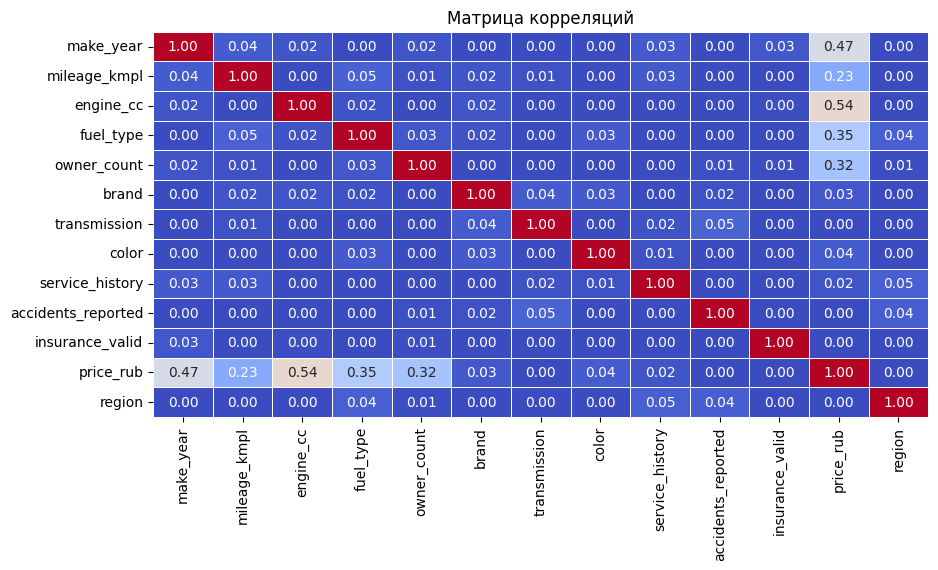

In [81]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

Вывод EDA:

Датасет содержит 8 000 записей без пропусков и дублей, что говорит о высоком качестве данных. Целевая переменная price_rub имеет близкое к нормальному распределение с центром около 600-700 тыс. рублей и лёгким правым хвостом, поэтому логарифмирование таргета не потребуется, как и остальных признаков, что также имеют неплохое распределение, не требующее полиномов и других преобразований. Сильнее всего цену определяют объём двигателя (0.54), год выпуска (0.47), тип топлива (0.35) и количество владельцев (0.32). Остальные признаки показывают слабую линейную корреляцию, но удаляться не будут - градиентный бустинг способен улавливать нелинейные зависимости, а встроенная регуляризация сама нивелирует вклад малозначимых переменных. Мультиколлинеарность между предикторами практически отсутствует.

## Предобработка

In [82]:
train_df[cat_cols] = train_df[cat_cols].astype('category')

X = train_df.drop(columns=['price_rub'])
y = train_df['price_rub']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=.2,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значенее целевой переменной в train: {y_train.mean():.3f}")
print(f"Среднее значенее целевой переменной в test: {y_test.mean():.3f}")

Размер обучающей выборки: (6400, 12)
Размер тестовой выборки: (1600, 12)
Среднее значенее целевой переменной в train: 683363.375
Среднее значенее целевой переменной в test: 684785.862


In [83]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [84]:
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['category']).columns

In [85]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough',
).set_output(transform='pandas')

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough',
).set_output(transform='pandas')

In [86]:
X_transformed_df = linear_preprocessor.fit_transform(X_train)
X_transformed_df.head()

,num__make_year,num__mileage_kmpl,num__engine_cc,num__owner_count,num__accidents_reported,cat__fuel_type_Electric,cat__fuel_type_Petrol,cat__brand_Chevrolet,cat__brand_Ford,cat__brand_Honda,cat__brand_Hyundai,cat__brand_Kia,cat__brand_Nissan,cat__brand_Tesla,cat__brand_Toyota,cat__brand_Volkswagen,cat__transmission_Manual,cat__color_Blue,cat__color_Gray,cat__color_Red,cat__color_Silver,cat__color_White,cat__service_history_Partial,cat__service_history_Unknown,cat__insurance_valid_Yes,cat__region_Москва,cat__region_СПб,cat__region_Сибирь,cat__region_Урал,cat__region_Юг
1467,0.34,-0.83,-0.23,1.40,-0.70,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
5768,1.17,-1.22,1.31,-0.70,2.19,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
5714,-1.56,2.11,0.54,-0.70,-0.70,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
1578,-0.14,0.70,1.31,-0.70,3.63,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
6958,0.10,-1.79,1.31,-0.00,-0.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [87]:
X_transformed_df = tree_preprocessor.fit_transform(X_train)
X_transformed_df.head()

,cat__fuel_type_Electric,cat__fuel_type_Petrol,cat__brand_Chevrolet,cat__brand_Ford,cat__brand_Honda,cat__brand_Hyundai,cat__brand_Kia,cat__brand_Nissan,cat__brand_Tesla,cat__brand_Toyota,cat__brand_Volkswagen,cat__transmission_Manual,cat__color_Blue,cat__color_Gray,cat__color_Red,cat__color_Silver,cat__color_White,cat__service_history_Partial,cat__service_history_Unknown,cat__insurance_valid_Yes,cat__region_Москва,cat__region_СПб,cat__region_Сибирь,cat__region_Урал,cat__region_Юг,remainder__make_year,remainder__mileage_kmpl,remainder__engine_cc,remainder__owner_count,remainder__accidents_reported
1467,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,2012,13.81,2000,5,0
5768,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,2019,11.83,4000,2,2
5714,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1996,28.60,3000,2,0
1578,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2008,21.51,4000,2,3
6958,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2010,8.94,4000,3,0


In [88]:
def get_linear_pipeline(model):
    return Pipeline(steps=[
        ('preprocessor', linear_preprocessor),
        ('model', model)
    ])
    
def get_tree_pipeline(model):
    return Pipeline(steps=[
        ('preprocessor', tree_preprocessor),
        ('model', model)
    ])

In [89]:
def calc_error_ratio(y_true, y_pred):
    return (y_pred - y_true) / y_true

def calc_overpricing_rate(y_true, y_pred):
    error_ratio = calc_error_ratio(y_true, y_pred)
    return (error_ratio > 0.20).mean()

def calc_underpricing_loss(y_true, y_pred):
    error_ratio = calc_error_ratio(y_true, y_pred)
    under_mask = error_ratio < -0.20

    return (y_true[under_mask] - y_pred[under_mask]).sum()

In [90]:
results = []

In [91]:
def evaluate_model(pipeline, X_train, y_train, name, params=None):
    scoring = {
        "RMSE":        "neg_root_mean_squared_error",
        "MAE":         "neg_mean_absolute_error",
        "R2":          "r2",
        "Overpricing": make_scorer(calc_overpricing_rate),
        "Loss":        make_scorer(calc_underpricing_loss),
    }
    
    cv_results = cross_validate(
        pipeline, 
        X_train, y_train, 
        cv=cv, 
        scoring=scoring,
        params=params,
        n_jobs=-1,
    )
    
    metrics = {
        "Model":       name,
        "RMSE":        -cv_results["test_RMSE"].mean(),
        "MAE":         -cv_results["test_MAE"].mean(),
        "R2":          cv_results["test_R2"].mean(),
        "Overpricing": cv_results["test_Overpricing"].mean(),
        "Loss":        cv_results["test_Loss"].mean(),
    }

    print(f"Доля переплат: {metrics['Overpricing']:.2%}")
    print(f"Упущенная выгода: {metrics['Loss']:,.0f} руб.")

    print("Итоговые метрики:")
    display(pd.DataFrame([metrics]))

    results.append(metrics)


## Обучение моделей в разных библиотеках

In [92]:
%%time

evaluate_model(
    get_linear_pipeline(LinearRegression()), 
    X_train, y_train, 
    "Linear [Baseline]"
)

Доля переплат: 13.31%
Упущенная выгода: 12,735,239 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Linear [Baseline],94805.37,75304.58,0.87,0.13,12735239.45


CPU times: user 37.3 ms, sys: 4.36 ms, total: 41.7 ms
Wall time: 984 ms


In [93]:
%%time

evaluate_model(
    get_linear_pipeline(Ridge(random_state=RANDOM_STATE)), 
    X_train, y_train, 
    "Ridge [Baseline]"
)

Доля переплат: 13.33%
Упущенная выгода: 12,676,799 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Ridge [Baseline],94804.46,75304.26,0.87,0.13,12676798.92


CPU times: user 31.8 ms, sys: 2.34 ms, total: 34.1 ms
Wall time: 226 ms


In [94]:
%%time

evaluate_model(
    get_linear_pipeline(Lasso(random_state=RANDOM_STATE)), 
    X_train, y_train, 
    "Lasso [Baseline]"
)

Доля переплат: 13.33%
Упущенная выгода: 12,734,786 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Lasso [Baseline],94804.34,75303.95,0.87,0.13,12734785.91


CPU times: user 34.3 ms, sys: 1.27 ms, total: 35.6 ms
Wall time: 248 ms


In [95]:
%%time

evaluate_model(
    get_linear_pipeline(ElasticNet(random_state=RANDOM_STATE)), 
    X_train, y_train, 
    "ElasticNet [Baseline]"
)

Доля переплат: 24.20%
Упущенная выгода: 32,623,400 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,ElasticNet [Baseline],142076.64,112408.59,0.71,0.24,32623400.14


CPU times: user 31.3 ms, sys: 2.15 ms, total: 33.4 ms
Wall time: 229 ms


In [96]:
%%time

evaluate_model(
    get_tree_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)), 
    X_train, y_train, 
    "Decision Tree [Baseline]"
)

Доля переплат: 20.66%
Упущенная выгода: 45,979,704 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Decision Tree [Baseline],146031.70,115907.41,0.70,0.21,45979704.20


CPU times: user 29.1 ms, sys: 3.91 ms, total: 33 ms
Wall time: 502 ms


In [97]:
%%time

rf_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

evaluate_model(rf_pipeline, X_train, y_train, "Random Forest [Baseline]")

Доля переплат: 15.08%
Упущенная выгода: 15,909,480 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Random Forest [Baseline],103074.35,81712.27,0.85,0.15,15909480.40


CPU times: user 86.2 ms, sys: 21.1 ms, total: 107 ms
Wall time: 16.1 s


In [98]:
%%time

xgb_model = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=RANDOM_STATE,
    enable_categorical=True,
)

evaluate_model(xgb_model, X_train, y_train, "XGBoost [Baseline]")

Доля переплат: 14.97%
Упущенная выгода: 17,060,619 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,XGBoost [Baseline],104943.29,83254.67,0.84,0.15,17060619.00


CPU times: user 40 ms, sys: 3.11 ms, total: 43.1 ms
Wall time: 2 s


In [99]:

%%time

catboost_model = CatBoostRegressor(
    loss_function='MAE',
    random_state=RANDOM_STATE,
    verbose=0,
)

FIXED_CATBOOST_FIT_PARAMS = {
    'cat_features': cat_cols.tolist()
}

evaluate_model(catboost_model, X_train, y_train, "CatBoost [Baseline]", FIXED_CATBOOST_FIT_PARAMS)

Доля переплат: 13.42%
Упущенная выгода: 12,762,881 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,CatBoost [Baseline],95755.96,76258.43,0.87,0.13,12762880.71


CPU times: user 200 ms, sys: 43.4 ms, total: 243 ms
Wall time: 50.2 s


In [100]:
%%time

lgbm_model = LGBMRegressor(
    objective='mae',
    random_state=RANDOM_STATE,
    verbose=0,
)

FIXED_LGBM_FIT_PARAMS = {
    'categorical_feature': cat_cols.tolist()
}

evaluate_model(lgbm_model, X_train, y_train, "LightGBM [Baseline]", FIXED_LGBM_FIT_PARAMS)

Доля переплат: 14.86%
Упущенная выгода: 13,923,925 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,LightGBM [Baseline],99424.71,79024.57,0.86,0.15,13923925.41


CPU times: user 40.1 ms, sys: 6.41 ms, total: 46.6 ms
Wall time: 2.51 s


In [101]:
%%time

alphas = [0.2, 0.3, 0.4]

for alpha in alphas:
    model = CatBoostRegressor(
        random_state=RANDOM_STATE,
        loss_function=f'Quantile:alpha={alpha}',
        verbose=0
    )

    evaluate_model(model, X_train, y_train, f"CatBoost Quantile [alpha={alpha}]", FIXED_CATBOOST_FIT_PARAMS)

Доля переплат: 4.64%
Упущенная выгода: 56,972,658 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,CatBoost Quantile [alpha=0.2],121613.32,98520.09,0.79,0.05,56972657.79


Доля переплат: 7.33%
Упущенная выгода: 34,366,721 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,CatBoost Quantile [alpha=0.3],106174.08,84696.02,0.84,0.07,34366721.00


Доля переплат: 10.27%
Упущенная выгода: 20,935,692 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,CatBoost Quantile [alpha=0.4],98452.65,78198.55,0.86,0.10,20935691.77


CPU times: user 595 ms, sys: 110 ms, total: 705 ms
Wall time: 2min 26s


In [102]:
def show_results(results):
    return pd.DataFrame(results) \
            .sort_values(by='MAE') \
            .style \
            .background_gradient(cmap='coolwarm', subset=['R2']) \
            .background_gradient(cmap='coolwarm_r', subset=['RMSE', 'MAE', 'Overpricing', 'Loss'])
            
show_results(results)

,Model,RMSE,MAE,R2,Overpricing,Loss
2,Lasso [Baseline],94804.344567,75303.951704,0.872743,0.133281,12734785.914080
1,Ridge [Baseline],94804.460493,75304.257378,0.872744,0.133281,12676798.924269
0,Linear [Baseline],94805.374127,75304.575016,0.872741,0.133125,12735239.454195
7,CatBoost [Baseline],95755.956154,76258.434577,0.870146,0.134219,12762880.711719
11,CatBoost Quantile [alpha=0.4],98452.649211,78198.552045,0.862790,0.102656,20935691.768446
8,LightGBM [Baseline],99424.707221,79024.569480,0.860055,0.148594,13923925.414044
5,Random Forest [Baseline],103074.345410,81712.268806,0.849626,0.150781,15909480.400000
6,XGBoost [Baseline],104943.292188,83254.665625,0.844093,0.149688,17060619.004687
10,CatBoost Quantile [alpha=0.3],106174.075301,84696.018290,0.840470,0.073281,34366720.995550
9,CatBoost Quantile [alpha=0.2],121613.319745,98520.085923,0.790737,0.046406,56972657.786746


Baseline-эксперимент показал конкурентные результаты у большинства моделей. Лидерами по всем метрикам стали линейные модели и CatBoost с практически идентичными показателями, что неожиданно - сильный результат линейных моделей говорит о выраженной линейной зависимости в данных, и это направление определённо стоит развивать через подбор гиперпараметров. LightGBM, Random Forest и XGBoost держатся в одной группе, Decision Tree ожидаемо замыкает таблицу с заметным отрывом.

Эксперименты с Quantile Loss были опущены из дальнейшего рассмотрения: хотя alpha=0.4 действительно снижает Overpricing Rate с 13.4% до 10.3%, Underpricing Loss при этом вырастает с 12.7 до 20.9 млн рублей - почти вдвое. При alpha=0.3 и 0.2 дисбаланс становится катастрофическим: Loss достигает 34 и 57 млн соответственно. Обе метрики одинаково важны для бизнеса, и такой размен неприемлем.

Следующий шаг - подбор гиперпараметров через Optuna для всех baseline-моделей, кроме Decision Tree: Линейные модели, CatBoost, LightGBM, Random Forest и XGBoost показали достаточно близкие результаты, чтобы после тюнинга расстановка сил могла измениться.

## Работа с параметрами модели (Тюнинг)

In [103]:
def run_optuna(build_pipeline_fn, build_best_pipeline_fn, name, n_trials=10):
    def objective(trial):
        result = build_pipeline_fn(trial)
        pipeline, params = result if isinstance(result, tuple) else (result, None)

        cv_results = cross_validate(
            pipeline, 
            X_train, y_train, 
            cv=cv, 
            scoring="neg_mean_absolute_error",
            params=params,
            n_jobs=-1
        )

        mean_score = -cv_results["test_score"].mean()

        trial.report(mean_score, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()

        return mean_score

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    fig1 = optuna.visualization.plot_optimization_history(study)
    fig2 = optuna.visualization.plot_param_importances(study)

    display(fig1)
    display(fig2)
    
    best_params = study.best_params
    print("Лучшие гиперпараметры:", best_params)
    best_value = study.best_value
    print("Лучшее среднее значение MAE на кросс-валидации:", best_value)

    result = build_best_pipeline_fn(best_params)
    pipeline, params = result if isinstance(result, tuple) else (result, None)

    evaluate_model(pipeline, X_train, y_train, name, params)

    return best_params

In [104]:
def get_params(trial):
    return {
        "fit_intercept": trial.suggest_categorical("fit_intercept", [True, False]),
        "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
    }

def build_pipeline_fn(trial):
    model = LinearRegression(**get_params(trial))
    return get_linear_pipeline(model)

def build_best_pipeline_fn(best_params):
    model = LinearRegression(**best_params)
    return get_linear_pipeline(model)

lr_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression [Best Params]")

[I 2026-03-09 15:39:38,179] A new study created in memory with name: no-name-48d5ff77-87ef-4588-a925-e3b3b1bd59ca


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-09 15:39:38,432] Trial 0 finished with value: 124091.67813954751 and parameters: {'fit_intercept': False, 'tol': 0.0029106359131330704}. Best is trial 0 with value: 124091.67813954751.
[I 2026-03-09 15:39:38,653] Trial 1 finished with value: 75304.57501647361 and parameters: {'fit_intercept': True, 'tol': 0.00020511104188433984}. Best is trial 1 with value: 75304.57501647361.
[I 2026-03-09 15:39:38,876] Trial 2 finished with value: 124091.67813954751 and parameters: {'fit_intercept': False, 'tol': 0.0015930522616241021}. Best is trial 1 with value: 75304.57501647361.
[I 2026-03-09 15:39:39,092] Trial 3 finished with value: 75304.57501647361 and parameters: {'fit_intercept': True, 'tol': 0.008706020878304856}. Best is trial 1 with value: 75304.57501647361.
[I 2026-03-09 15:39:39,303] Trial 4 finished with value: 75304.57501647361 and parameters: {'fit_intercept': True, 'tol': 0.0002310201887845295}. Best is trial 1 with value: 75304.57501647361.
[I 2026-03-09 15:39:39,528] Tr

Лучшие гиперпараметры: {'fit_intercept': True, 'tol': 0.00020511104188433984}
Лучшее среднее значение MAE на кросс-валидации: 75304.57501647361
Доля переплат: 13.31%
Упущенная выгода: 12,735,239 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Logistic Regression [Best Params],94805.37,75304.58,0.87,0.13,12735239.45


In [105]:
def get_params(trial):
    return {
        "alpha": trial.suggest_float("alpha", 1e-6, 1e6, log=True),
        "fit_intercept": trial.suggest_categorical("fit_intercept", [True, False]),
        "tol": trial.suggest_float("tol", 1e-6, 1e-2, log=True),
    }

def build_pipeline_fn(trial):
    model = Ridge(**get_params(trial))
    return get_linear_pipeline(model)

def build_best_pipeline_fn(best_params):
    model = Ridge(**best_params)
    return get_linear_pipeline(model)

ridge_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Ridge [Best Params]")

def build_pipeline_fn(trial):
    model = Lasso(**get_params(trial))
    return get_linear_pipeline(model)

def build_best_pipeline_fn(best_params):
    model = Lasso(**best_params)
    return get_linear_pipeline(model)

lasso_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Lasso [Best Params]")

[I 2026-03-09 15:39:41,067] A new study created in memory with name: no-name-1f134439-e0b8-4f1e-8d4d-8b2c247834d6


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-09 15:39:41,293] Trial 0 finished with value: 75304.55899585036 and parameters: {'alpha': 0.031223488672887795, 'fit_intercept': True, 'tol': 0.0002481040974867811}. Best is trial 0 with value: 75304.55899585036.
[I 2026-03-09 15:39:41,527] Trial 1 finished with value: 75304.57497822163 and parameters: {'alpha': 7.451156502282094e-05, 'fit_intercept': True, 'tol': 0.0029154431891537554}. Best is trial 0 with value: 75304.55899585036.
[I 2026-03-09 15:39:41,730] Trial 2 finished with value: 75345.27671362205 and parameters: {'alpha': 16.344819951627372, 'fit_intercept': True, 'tol': 0.00757947995334801}. Best is trial 0 with value: 75304.55899585036.
[I 2026-03-09 15:39:41,930] Trial 3 finished with value: 158282.06229893927 and parameters: {'alpha': 9756.896309824397, 'fit_intercept': True, 'tol': 5.415244119402541e-06}. Best is trial 0 with value: 75304.55899585036.
[I 2026-03-09 15:39:42,132] Trial 4 finished with value: 75304.57271871595 and parameters: {'alpha': 0.004476

Лучшие гиперпараметры: {'alpha': 0.29705701356941455, 'fit_intercept': True, 'tol': 0.00011400863701127338}
Лучшее среднее значение MAE на кросс-валидации: 75304.423289211
Доля переплат: 13.31%
Упущенная выгода: 12,733,191 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Ridge [Best Params],94805.05,75304.42,0.87,0.13,12733190.96


[I 2026-03-09 15:39:43,665] A new study created in memory with name: no-name-2990274f-1f93-4203-99d3-7d12e118a4c8


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-09 15:39:43,908] Trial 0 finished with value: 75304.55500491652 and parameters: {'alpha': 0.031223488672887795, 'fit_intercept': True, 'tol': 0.0002481040974867811}. Best is trial 0 with value: 75304.55500491652.
[I 2026-03-09 15:39:44,161] Trial 1 finished with value: 75304.5749635763 and parameters: {'alpha': 7.451156502282094e-05, 'fit_intercept': True, 'tol': 0.0029154431891537554}. Best is trial 0 with value: 75304.55500491652.
[I 2026-03-09 15:39:44,365] Trial 2 finished with value: 75293.89924843531 and parameters: {'alpha': 16.344819951627372, 'fit_intercept': True, 'tol': 0.00757947995334801}. Best is trial 2 with value: 75293.89924843531.
[I 2026-03-09 15:39:44,577] Trial 3 finished with value: 81096.6418476059 and parameters: {'alpha': 9756.896309824397, 'fit_intercept': True, 'tol': 5.415244119402541e-06}. Best is trial 2 with value: 75293.89924843531.
[I 2026-03-09 15:39:44,835] Trial 4 finished with value: 75304.57222475123 and parameters: {'alpha': 0.004476173

Лучшие гиперпараметры: {'alpha': 16.344819951627372, 'fit_intercept': True, 'tol': 0.00757947995334801}
Лучшее среднее значение MAE на кросс-валидации: 75293.89924843531
Доля переплат: 13.33%
Упущенная выгода: 12,601,962 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Lasso [Best Params],94788.49,75293.90,0.87,0.13,12601962.06


In [106]:
def get_params(trial):
    return {
        "alpha": trial.suggest_float("alpha", 1e-6, 1e6, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        "fit_intercept": trial.suggest_categorical("fit_intercept", [True, False]),
        "tol": trial.suggest_float("tol", 1e-6, 1e-2, log=True),
    }

def build_pipeline_fn(trial):
    model = ElasticNet(**get_params(trial))
    return get_linear_pipeline(model)

def build_best_pipeline_fn(best_params):
    model = ElasticNet(**best_params)
    return get_linear_pipeline(model)

en_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "ElasticNet [Best Params]")

[I 2026-03-09 15:39:47,560] A new study created in memory with name: no-name-653439c1-900d-4e7f-b350-b10b3e1d8a16


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-09 15:39:47,946] Trial 0 finished with value: 75313.37022214437 and parameters: {'alpha': 0.031223488672887795, 'l1_ratio': 0.9507143064099162, 'fit_intercept': True, 'tol': 4.2079886696066345e-06}. Best is trial 0 with value: 75313.37022214437.
[I 2026-03-09 15:39:48,375] Trial 1 finished with value: 75304.39179074639 and parameters: {'alpha': 7.446192235373425e-05, 'l1_ratio': 0.05808361216819946, 'fit_intercept': True, 'tol': 0.0006796578090758161}. Best is trial 1 with value: 75304.39179074639.
[I 2026-03-09 15:39:48,751] Trial 2 finished with value: 75304.57487572714 and parameters: {'alpha': 1.7660944735776943e-06, 'l1_ratio': 0.9699098521619943, 'fit_intercept': True, 'tol': 5.337032762603957e-06}. Best is trial 1 with value: 75304.39179074639.
[I 2026-03-09 15:39:49,181] Trial 3 finished with value: 75304.31770612611 and parameters: {'alpha': 0.00015880132371526778, 'l1_ratio': 0.3042422429595377, 'fit_intercept': True, 'tol': 1.461896279370496e-05}. Best is trial 3 

Лучшие гиперпараметры: {'alpha': 0.00015880132371526778, 'l1_ratio': 0.3042422429595377, 'fit_intercept': True, 'tol': 1.461896279370496e-05}
Лучшее среднее значение MAE на кросс-валидации: 75304.31770612611
Доля переплат: 13.33%
Упущенная выгода: 12,700,083 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,ElasticNet [Best Params],94804.80,75304.32,0.87,0.13,12700082.83


In [107]:
def get_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        "bootstrap": True,
    }

def build_pipeline_fn(trial):
    model = RandomForestRegressor(**get_params(trial), n_jobs=-1)
    return get_tree_pipeline(model)

def build_best_pipeline_fn(best_params):
    model = RandomForestRegressor(**best_params, n_jobs=-1)
    return get_tree_pipeline(model)

rf_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest [Best Params]")

[I 2026-03-09 15:39:51,711] A new study created in memory with name: no-name-13168f3e-9635-44b6-83ae-a4a1028ca1a8


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-09 15:39:56,426] Trial 0 finished with value: 104241.93189364091 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'max_samples': 0.9330880728874675}. Best is trial 0 with value: 104241.93189364091.
[I 2026-03-09 15:40:02,095] Trial 1 finished with value: 113822.05216833195 and parameters: {'n_estimators': 341, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_samples': 0.5917022549267169}. Best is trial 0 with value: 104241.93189364091.
[I 2026-03-09 15:40:07,648] Trial 2 finished with value: 100902.82096885862 and parameters: {'n_estimators': 222, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_samples': 0.6831809216468459}. Best is trial 2 with value: 100902.82096885862.
[I 2026-03-09 15:40:21,488] Trial 3 finished with value: 82214.42147721471 and parameters: {'n_estimators': 282, 'max_depth': 17, 'min_sam

Лучшие гиперпараметры: {'n_estimators': 282, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 11, 'max_features': None, 'max_samples': 0.5852620618436457}
Лучшее среднее значение MAE на кросс-валидации: 82214.42147721471
Доля переплат: 15.33%
Упущенная выгода: 15,273,214 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Random Forest [Best Params],103586.98,82265.59,0.85,0.15,15273213.73


In [108]:
FIXED_XGB_PARAMS = {
    "objective": "reg:absoluteerror",
    "enable_categorical": True,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

def get_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

def build_pipeline_fn(trial):
    model = XGBRegressor(**get_params(trial), **FIXED_XGB_PARAMS)
    return model

def build_best_pipeline_fn(best_params):
    model = XGBRegressor(**best_params, **FIXED_XGB_PARAMS)
    return model

xgb_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "XGBoost [Best Params]")

[I 2026-03-09 15:40:59,977] A new study created in memory with name: no-name-4e534dfd-750f-4274-b074-104fb108029e


  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-03-09 15:41:40,404] Trial 0 finished with value: 82148.2671875 and parameters: {'n_estimators': 1062, 'max_depth': 10, 'learning_rate': 0.05395030966670229, 'gamma': 0.0006155564318973012, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}. Best is trial 0 with value: 82148.2671875.
[I 2026-03-09 15:41:57,120] Trial 1 finished with value: 80730.278125 and parameters: {'n_estimators': 587, 'max_depth': 9, 'learning_rate': 0.039913058785616795, 'gamma': 0.004619347374377372, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 5.360294728728285}. Best is trial 1 with value: 80730.278125.
[I 2026-03-09 15:42:11,982] Trial 2 finished with value: 78014.7703125 and parameters: {'n_estimators': 1749, 'max_depth': 4, 'learning_rate': 0.015199348301309814, 'gamma': 2.9324868872723725e-07, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 2 with value: 78014.7703125.
[I 2026-03-09 15:42:23,033] Trial 3 finished with value: 78686.1

Лучшие гиперпараметры: {'n_estimators': 957, 'max_depth': 3, 'learning_rate': 0.04833180632488466, 'gamma': 3.320625892007924e-05, 'reg_alpha': 1.254134495897175e-07, 'reg_lambda': 0.00028614897264046574}
Лучшее среднее значение MAE на кросс-валидации: 77425.0109375
Доля переплат: 14.06%
Упущенная выгода: 13,391,280 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,XGBoost [Best Params],97433.88,77425.01,0.87,0.14,13391279.66


In [110]:
FIXED_CATBOOST_PARAMS = {
    "loss_function": "MAE",
    "random_state": RANDOM_STATE,
    "thread_count": -1,
    "verbose": 0,
}

def get_params(trial):
    return {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
    }

def build_pipeline_fn(trial):
    model = CatBoostRegressor(**get_params(trial), **FIXED_CATBOOST_PARAMS)
    return model, FIXED_CATBOOST_FIT_PARAMS

def build_best_pipeline_fn(best_params):
    model = CatBoostRegressor(**best_params, **FIXED_CATBOOST_PARAMS)
    return model, FIXED_CATBOOST_FIT_PARAMS

cb_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "CatBoost [Best Params]")

[I 2026-03-09 15:55:54,428] A new study created in memory with name: no-name-95b0e178-13ee-407d-8e5f-fba5a34c6a35


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-09 15:59:00,440] Trial 0 finished with value: 77451.26421280879 and parameters: {'iterations': 1062, 'depth': 10, 'learning_rate': 0.05395030966670229, 'l2_leaf_reg': 3.968793330444372}. Best is trial 0 with value: 77451.26421280879.
[I 2026-03-09 15:59:25,702] Trial 1 finished with value: 76223.77136311134 and parameters: {'iterations': 734, 'depth': 4, 'learning_rate': 0.011430983876313222, 'l2_leaf_reg': 7.348118405270449}. Best is trial 1 with value: 76223.77136311134.
[I 2026-03-09 16:01:19,646] Trial 2 finished with value: 76364.7567426906 and parameters: {'iterations': 1402, 'depth': 8, 'learning_rate': 0.010485387725194618, 'l2_leaf_reg': 9.330606024425668}. Best is trial 1 with value: 76223.77136311134.
[I 2026-03-09 16:02:13,890] Trial 3 finished with value: 75957.10463868403 and parameters: {'iterations': 1749, 'depth': 4, 'learning_rate': 0.015199348301309814, 'l2_leaf_reg': 1.5254729458052607}. Best is trial 3 with value: 75957.10463868403.
[I 2026-03-09 16:03:1

Лучшие гиперпараметры: {'iterations': 1418, 'depth': 4, 'learning_rate': 0.019594972058679168, 'l2_leaf_reg': 2.324672848950434}
Лучшее среднее значение MAE на кросс-валидации: 75953.21016081123
Доля переплат: 13.50%
Упущенная выгода: 12,729,675 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,CatBoost [Best Params],95525.28,75953.21,0.87,0.14,12729675.06


In [111]:
FIXED_LGBM_PARAMS = {
    "loss_function": 'mae',
    "random_state": RANDOM_STATE,
    "verbose": -1,
}

def get_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
    }

def build_pipeline_fn(trial):
    model = LGBMRegressor(**get_params(trial), **FIXED_LGBM_PARAMS)
    return model, FIXED_LGBM_FIT_PARAMS

def build_best_pipeline_fn(best_params):
    model = LGBMRegressor(**best_params, **FIXED_LGBM_PARAMS)
    return model, FIXED_LGBM_FIT_PARAMS

lgbm_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "LightGBM [Best Params]")

[I 2026-03-09 16:09:43,920] A new study created in memory with name: no-name-a1171bdf-3ba3-45e2-9c61-f74dbfc1457a


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-09 16:09:59,389] Trial 0 finished with value: 83664.39814319558 and parameters: {'n_estimators': 1062, 'max_depth': 10, 'learning_rate': 0.05395030966670229, 'num_leaves': 161, 'min_child_samples': 19, 'reg_alpha': 1.7699302940633311e-07, 'reg_lambda': 2.9152036385288193e-08}. Best is trial 0 with value: 83664.39814319558.
[I 2026-03-09 16:10:09,355] Trial 1 finished with value: 83006.17524898391 and parameters: {'n_estimators': 1800, 'max_depth': 7, 'learning_rate': 0.051059032093947576, 'num_leaves': 24, 'min_child_samples': 98, 'reg_alpha': 0.04566054873446119, 'reg_lambda': 4.997040685255803e-07}. Best is trial 1 with value: 83006.17524898391.
[I 2026-03-09 16:10:11,741] Trial 2 finished with value: 77835.06446982714 and parameters: {'n_estimators': 772, 'max_depth': 4, 'learning_rate': 0.02014847788415866, 'num_leaves': 144, 'min_child_samples': 46, 'reg_alpha': 2.1371407316372935e-06, 'reg_lambda': 0.000784915956255507}. Best is trial 2 with value: 77835.06446982714.
[

Лучшие гиперпараметры: {'n_estimators': 632, 'max_depth': 4, 'learning_rate': 0.011097554561103107, 'num_leaves': 97, 'min_child_samples': 42, 'reg_alpha': 1.481809088646707e-06, 'reg_lambda': 0.04264813784432918}
Лучшее среднее значение MAE на кросс-валидации: 77589.86989211726
Доля переплат: 14.67%
Упущенная выгода: 12,564,364 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,LightGBM [Best Params],97643.06,77589.87,0.87,0.15,12564363.55


In [112]:
show_results(results)

,Model,RMSE,MAE,R2,Overpricing,Loss
14,Lasso [Best Params],94788.492696,75293.899248,0.872787,0.133281,12601962.056065
2,Lasso [Baseline],94804.344567,75303.951704,0.872743,0.133281,12734785.914080
1,Ridge [Baseline],94804.460493,75304.257378,0.872744,0.133281,12676798.924269
15,ElasticNet [Best Params],94804.797360,75304.317706,0.872743,0.133281,12700082.829347
13,Ridge [Best Params],94805.051737,75304.423289,0.872742,0.133125,12733190.959076
12,Logistic Regression [Best Params],94805.374127,75304.575016,0.872741,0.133125,12735239.454195
0,Linear [Baseline],94805.374127,75304.575016,0.872741,0.133125,12735239.454195
18,CatBoost [Best Params],95525.282913,75953.210161,0.870783,0.135000,12729675.064414
7,CatBoost [Baseline],95755.956154,76258.434577,0.870146,0.134219,12762880.711719
17,XGBoost [Best Params],97433.875000,77425.010938,0.865535,0.140625,13391279.664844


Подбор гиперпараметров через Optuna подтвердил результаты baseline-эксперимента: линейные модели (Lasso, Ridge, ElasticNet) уверенно занимают верхние строчки таблицы с RMSE ~94 800 и R^2 ~0.873, практически не оставляя пространства для улучшения относительно базовых версий. Это говорит о том, что зависимость в данных действительно близка к линейной и регуляризация лишь незначительно корректирует результат. Среди моделей бустинга лучшим оказался CatBoost с RMSE 95 525 и R^2 0.871 - он вплотную приблизился к линейным моделям и показал наименьший Overpricing Rate среди бустингов (13.5%). XGBoost и LightGBM после тюнинга также улучшились, однако заметно уступают как линейным моделям, так и CatBoost.

Интересно, что два явных лидера - Lasso и CatBoost - устроены принципиально по-разному: линейная модель улавливает прямые зависимости и хорошо обобщает, тогда как CatBoost строит ансамбль деревьев и способен захватывать нелинейные взаимодействия между признаками. Это открывает возможность объединить их сильные стороны через стекинг - если каждая модель ошибается в разных сегментах данных, мета-модель сможет скомпенсировать слабости каждой и потенциально превзойти обе по отдельности.

---

### ! Вопрос по выполнению работы

Столкнулся с проблемой, что передать параметр params в fit или cross_validate для CatBoost нельзя в случае работы с Stacking. Есть ли какое-то решение для данной проблемы? То есть как обрабатывать категорильные призанки через cat_features, учитывая, что в сам класс CatBoostRegressor передать массив строк тоже нельзя.

Вышел из положения отдельной обработкой категорий, но это, вероятно, отличается от модели, что обучалась с параметром cat_features с optuna.

In [113]:
lasso_pipe = get_linear_pipeline(
    Lasso(**lasso_best_params, random_state=RANDOM_STATE)
)
catboost_pipe = get_tree_pipeline(
    CatBoostRegressor(**cb_best_params, random_seed=RANDOM_STATE, verbose=0)
)

stacking_reg = StackingRegressor(
    estimators=[
        ("lasso", lasso_pipe),
        ("cb", catboost_pipe)
    ],
    final_estimator=LinearRegression(),
    cv=cv,
    n_jobs=-1,
)

evaluate_model(stacking_reg, X_train, y_train, "Stack [lasso+catboost/LR]")

Доля переплат: 13.34%
Упущенная выгода: 12,831,874 руб.
Итоговые метрики:


,Model,RMSE,MAE,R2,Overpricing,Loss
0,Stack [lasso+catboost/LR],94809.65,75311.89,0.87,0.13,12831874.37


In [114]:
show_results(results)

,Model,RMSE,MAE,R2,Overpricing,Loss
14,Lasso [Best Params],94788.492696,75293.899248,0.872787,0.133281,12601962.056065
2,Lasso [Baseline],94804.344567,75303.951704,0.872743,0.133281,12734785.914080
1,Ridge [Baseline],94804.460493,75304.257378,0.872744,0.133281,12676798.924269
15,ElasticNet [Best Params],94804.797360,75304.317706,0.872743,0.133281,12700082.829347
13,Ridge [Best Params],94805.051737,75304.423289,0.872742,0.133125,12733190.959076
12,Logistic Regression [Best Params],94805.374127,75304.575016,0.872741,0.133125,12735239.454195
0,Linear [Baseline],94805.374127,75304.575016,0.872741,0.133125,12735239.454195
20,Stack [lasso+catboost/LR],94809.646836,75311.885430,0.872729,0.133438,12831874.371402
18,CatBoost [Best Params],95525.282913,75953.210161,0.870783,0.135000,12729675.064414
7,CatBoost [Baseline],95755.956154,76258.434577,0.870146,0.134219,12762880.711719


Объединение Lasso и CatBoost под управлением мета-модели дало небольшой прирост качества, превзойдя бустинг. Для дальнейшего SHAP-анализа и финальной оценки отобраны три модели с принципиально разными механизмами: Lasso [Best Params], Stacking [Lasso + CatBoost] и CatBoost [Best Params] - это позволит сравнить интерпретируемость и поведение моделей с разной внутренней логикой.

## Интерпретация и бизнес-анализ

### ! Вопрос по выполнению работы

Здесь тоже есть вопросы:
1. Есть ли иной способ использовать SHAP с pipeline, чем представлен в коде ниже? В уроке курса разбирались простые примеры, где не было категорильных признаков и не требовалась их обработка, поэтому можно было передать сразу модель в shap, но в более сложных датасетах в результате получается pipeline, с которым shap работать не может. Буду рад, если получится закрепить именно код такого решения.
2. Есть ли практичный способ применить SHAP к стекингу? Судя по документации, KernelExplainer вычислительно слишком дорог для реальных данных, и полноценный анализ становится недоступным. При этом стекинг может превосходить базовые модели по метрикам, но его невозможно интерпретировать - и приходится от него отказываться. Есть ли альтернативы, которые позволили бы объяснить предсказания стекинга так же, как это делается для деревьев?

In [115]:
def show_model_analysis(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    display(pd.DataFrame([{
        "Model": name,
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "Overpricing": calc_overpricing_rate(y_test.values, y_pred),
        "Loss": calc_underpricing_loss(y_test.values, y_pred),
    }]))

    error_df = X_test.copy().reset_index(drop=True)
    error_df["error_ratio"] = calc_error_ratio(y_test.values, y_pred)
    error_df["overpricing"] = error_df["error_ratio"] > 0.20
    error_df["underpricing"] = error_df["error_ratio"] < -0.20

    for col in ["brand", "region"]:
        analysis = error_df.groupby(col, observed=True).agg(
            count=("error_ratio", "count"),
            overpricing_rate=("overpricing", "mean"),
            underpricing_rate=("underpricing", "mean"),
        ).sort_values("overpricing_rate", ascending=False).round(3)
        display(analysis.style
            .format({'overpricing_rate': '{:.2%}', 'underpricing_rate': '{:.2%}'})
            .background_gradient(cmap='coolwarm_r')
        )

    if isinstance(model, StackingRegressor):
        print("Стекинг: SHAP пропущен.")
        return

    if hasattr(model, "named_steps"):
        preprocessor = model[:-1]
        estimator = model[-1]
        X_transformed = preprocessor.transform(X_test)
        
        if hasattr(X_transformed, 'values'):
            X_transformed = X_transformed.values.astype(float)

        raw_feature_names = preprocessor.get_feature_names_out()
        clean_feature_names = [f.replace("num__", "").replace("cat__", "").replace("preprocessor__", "")
                        for f in raw_feature_names]

        if isinstance(estimator, CatBoostRegressor):
            X_shap = pd.DataFrame(X_transformed, columns=raw_feature_names)
        else:
            X_shap = pd.DataFrame(X_transformed, columns=clean_feature_names)
    else:
        estimator = model
        X_shap = X_test.reset_index(drop=True).copy()

    if isinstance(estimator, (Lasso, Ridge, ElasticNet, LinearRegression)):
        explainer = LinearExplainer(estimator, X_shap)
    else:
        explainer = TreeExplainer(estimator)

    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
        
    summary_plot(shap_values, X_shap, plot_size=(16, 8), show=True)
    summary_plot(shap_values, X_shap, plot_type="bar", plot_size=(16, 8), show=True)
    force_plot(
        explainer.expected_value, 
        shap_values[0], 
        X_shap.iloc[0],
        matplotlib=True,
        show=True
    )

1. Lasso

,Model,RMSE,MAE,R2,Overpricing,Loss
0,Lasso,98496.02,78861.51,0.86,0.14,17829413.55


,count,overpricing_rate,underpricing_rate
brand,,,
Toyota,152,18.40%,7.20%
Volkswagen,173,16.20%,7.50%
Ford,147,15.00%,5.40%
Tesla,163,14.70%,8.00%
Hyundai,166,13.30%,5.40%
Kia,167,12.60%,6.00%
Honda,132,12.10%,2.30%
Nissan,170,11.80%,7.10%
Chevrolet,159,11.30%,6.90%


,count,overpricing_rate,underpricing_rate
region,,,
Урал,276,16.30%,4.30%
Сибирь,253,15.00%,5.50%
Юг,293,14.70%,7.80%
Москва,249,13.70%,7.20%
СПб,267,12.70%,8.60%
Дальний Восток,262,9.20%,8.00%


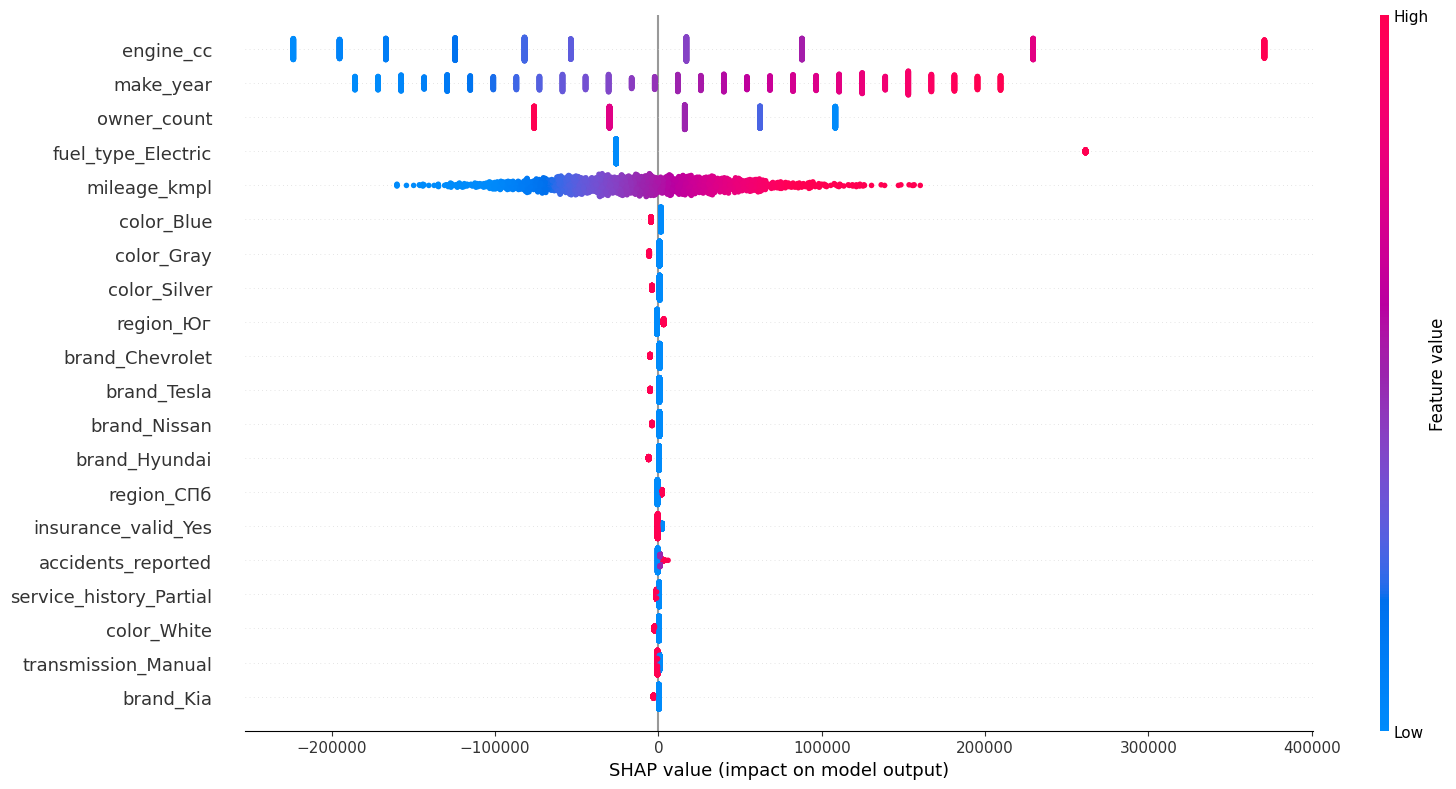

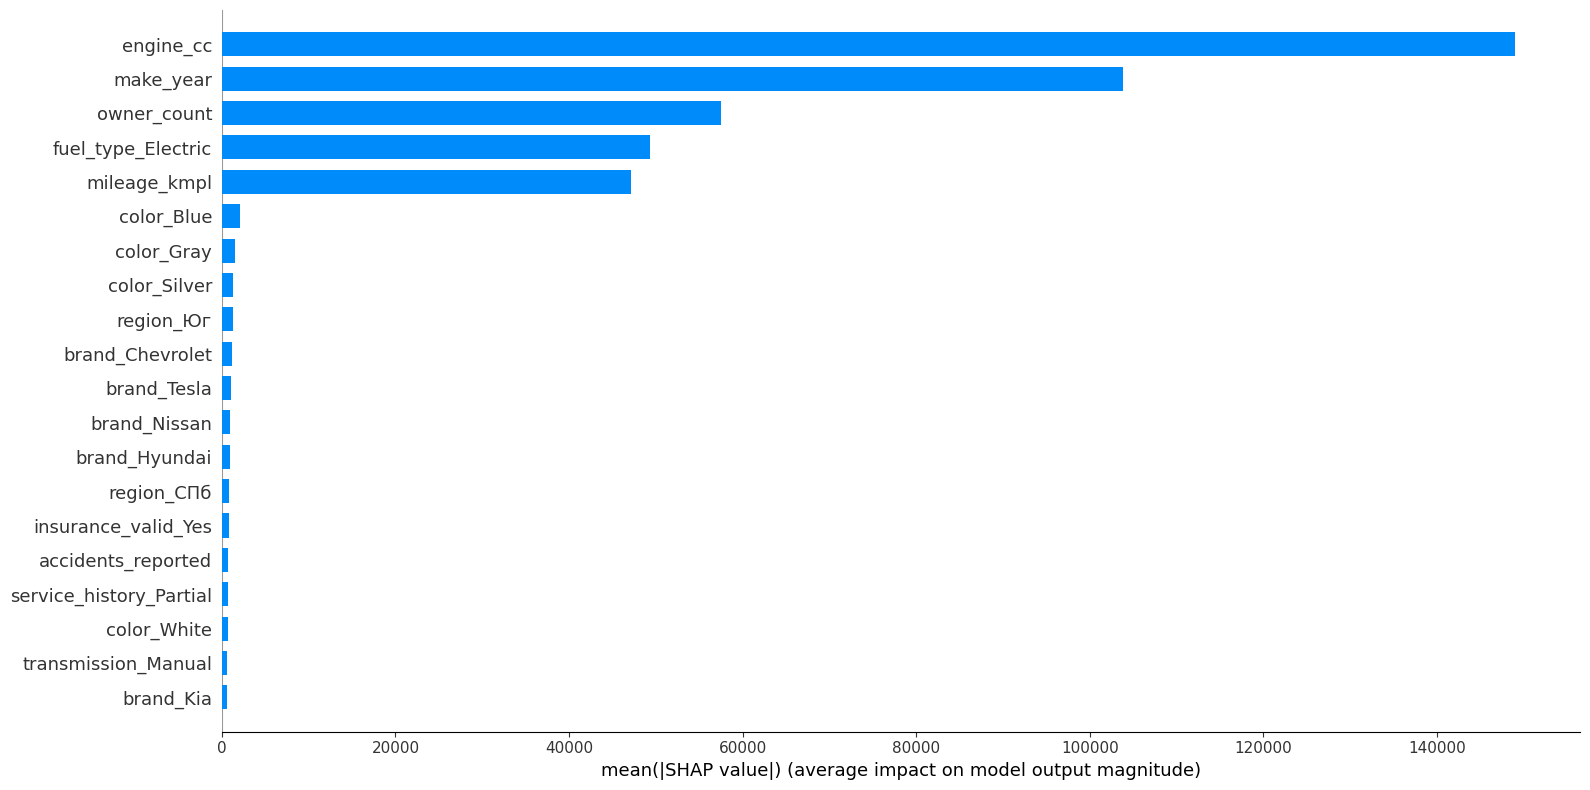

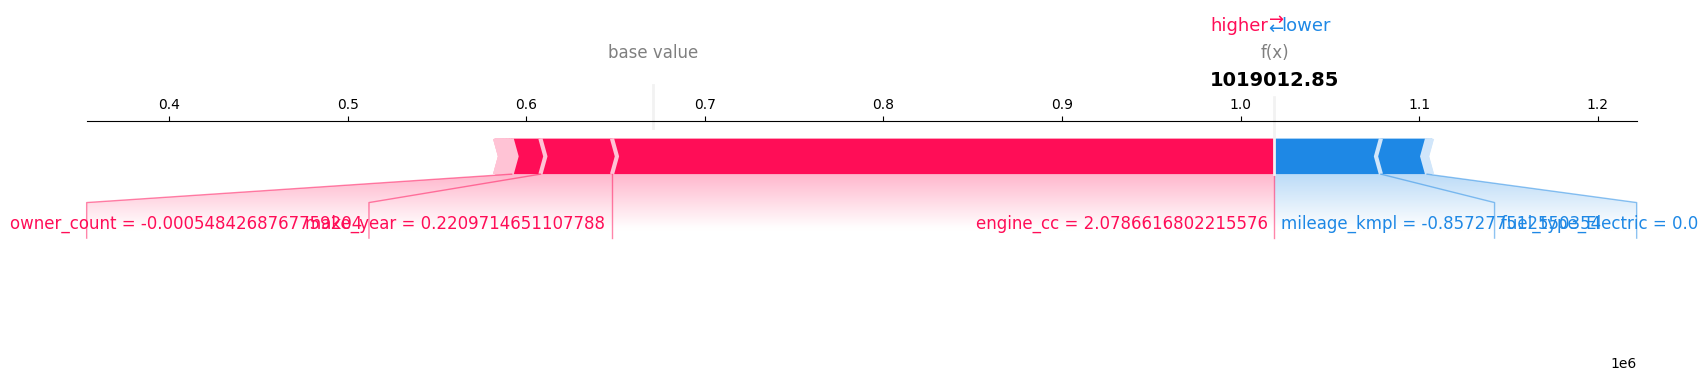

In [116]:
lasso_pipe.fit(X_train, y_train)

show_model_analysis(lasso_pipe, X_test, y_test, "Lasso")

2. Stack [Lasso + CatBoost]

In [117]:
stacking_reg.fit(X_train, y_train)

show_model_analysis(stacking_reg, X_test, y_test, "Stack")

,Model,RMSE,MAE,R2,Overpricing,Loss
0,Stack,98500.52,78853.12,0.86,0.14,17718819.39


,count,overpricing_rate,underpricing_rate
brand,,,
Toyota,152,18.40%,7.20%
Volkswagen,173,16.20%,7.50%
Ford,147,15.00%,5.40%
Tesla,163,14.70%,8.00%
Hyundai,166,12.70%,5.40%
Honda,132,12.10%,2.30%
Kia,167,12.00%,6.00%
Nissan,170,11.80%,7.10%
Chevrolet,159,11.30%,6.90%


,count,overpricing_rate,underpricing_rate
region,,,
Урал,276,15.90%,4.30%
Сибирь,253,15.00%,5.50%
Юг,293,14.70%,7.80%
Москва,249,13.30%,6.80%
СПб,267,12.70%,8.60%
Дальний Восток,262,9.20%,8.00%


Стекинг: SHAP пропущен.


3. CatBoost

,Model,RMSE,MAE,R2,Overpricing,Loss
0,CatBoost,99058.35,79325.47,0.86,0.13,17847197.50


,count,overpricing_rate,underpricing_rate
brand,,,
Toyota,152,17.80%,6.60%
Volkswagen,173,16.20%,7.50%
Tesla,163,15.30%,9.20%
Ford,147,14.30%,5.40%
Hyundai,166,13.30%,4.80%
Chevrolet,159,12.60%,6.30%
Nissan,170,11.80%,7.10%
Honda,132,11.40%,2.30%
BMW,171,11.10%,11.70%


,count,overpricing_rate,underpricing_rate
region,,,
Урал,276,15.90%,4.70%
Сибирь,253,15.40%,5.90%
Юг,293,14.00%,7.50%
Москва,249,13.30%,6.80%
СПб,267,13.10%,9.00%
Дальний Восток,262,8.80%,7.30%


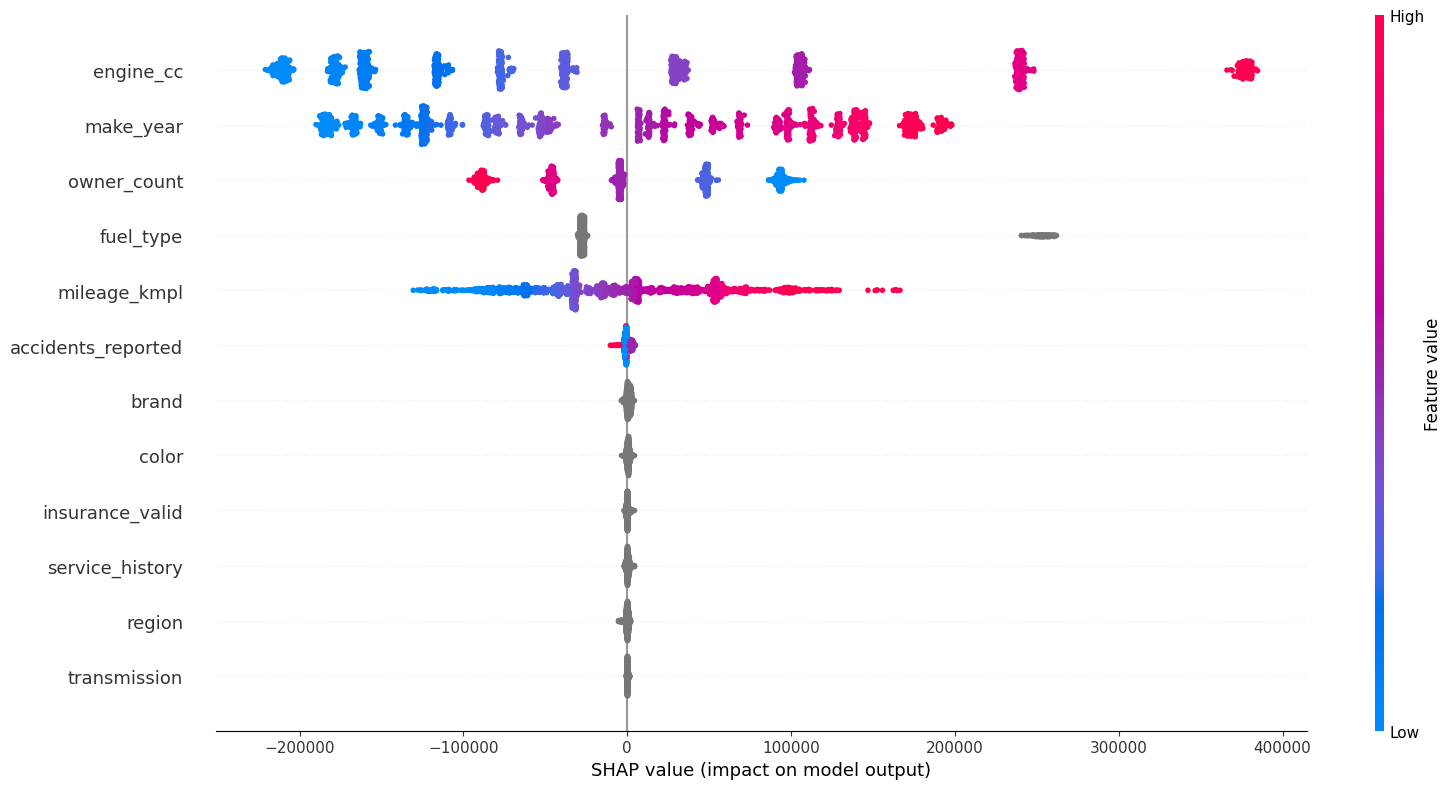

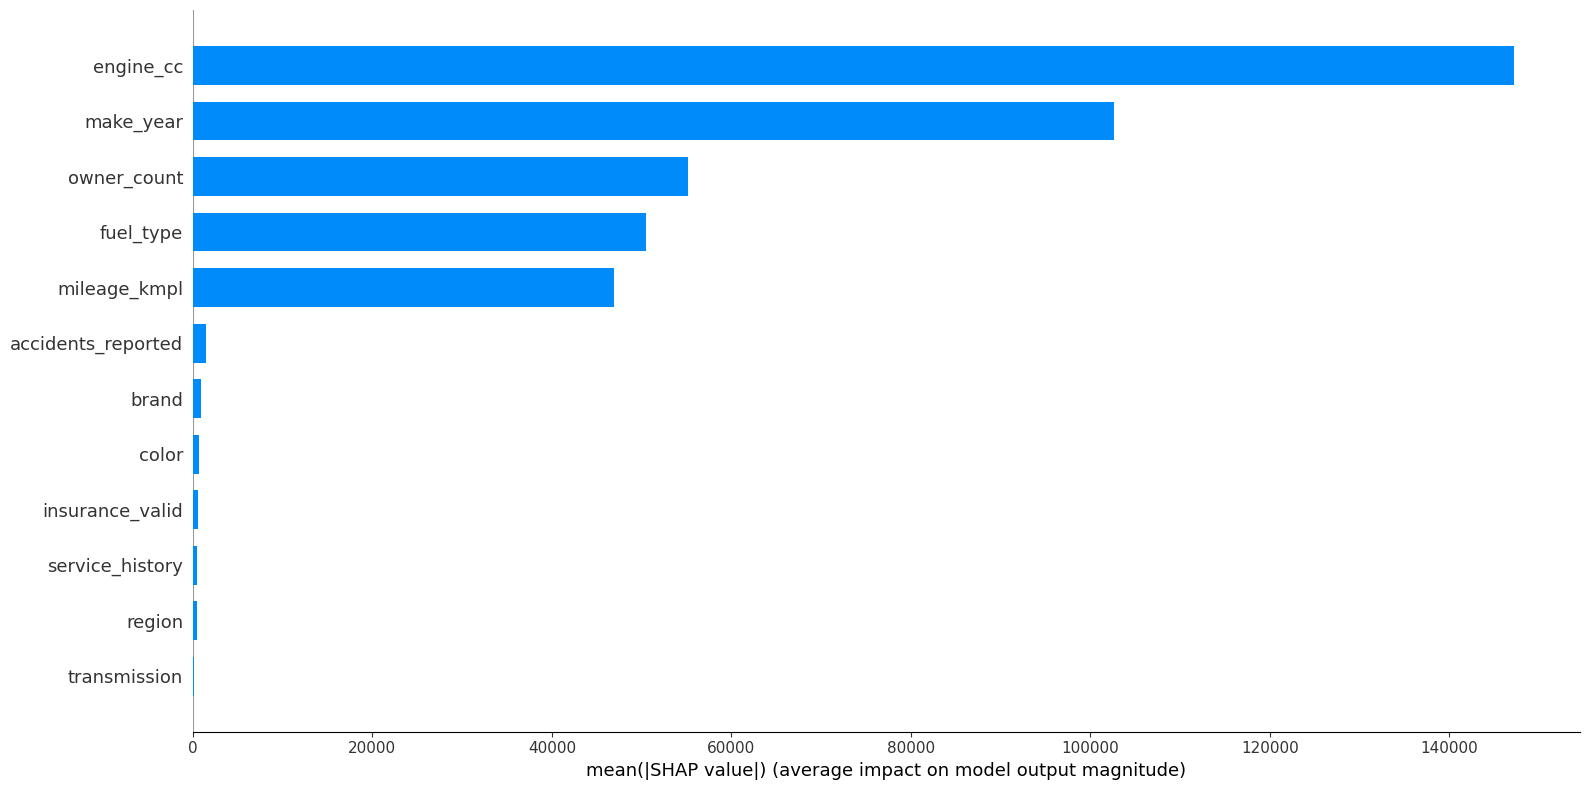

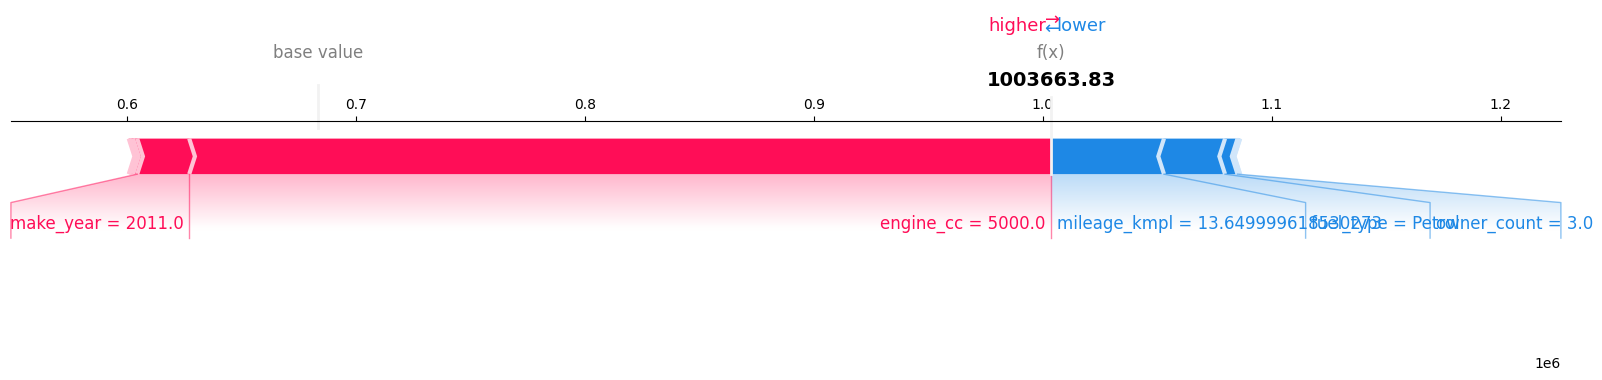

In [118]:
catboost_model = CatBoostRegressor(**cb_best_params, random_seed=RANDOM_STATE, verbose=0)
catboost_model.fit(X_train, y_train, cat_features=cat_cols.tolist())

show_model_analysis(catboost_model, X_test, y_test, "CatBoost")

SHAP-анализ обеих моделей дал согласованные результаты. Топ-5 признаков по вкладу в прогноз: engine_cc, make_year, owner_count, fuel_type_Electric и mileage_kmpl - и это полностью совпадает с бизнес-логикой: чем больше объём двигателя и новее автомобиль, тем выше цена, чем больше пробег и владельцев - тем ниже. Электромобили ожидаемо формируют отдельный премиальный сегмент. Специфические признаки (color, insurance_valid, service_history, accidents_reported) вносят пренебрежимо малый вклад - их средний SHAP-импакт на порядок ниже технических характеристик, что говорит об отсутствии случайных корреляций в решениях модели.

По бизнес-метрикам все три модели показывают схожий Overpricing Rate около 13-14%, при этом Stacking незначительно уступает по MAE. Модели систематически чаще ошибаются в сторону завышения, чем занижения, что для бизнеса предпочтительнее - риск упущенной выгоды ниже риска убытка от переплаты.

По разрезу категорий наиболее проблемными марками оказались Toyota (18.4%), Volkswagen (16.2%) и Tesla (15.3%) - здесь риск переплаты выше среднего и рекомендуется ручная проверка. По регионам лидируют Урал (16.7%) и Сибирь (15.4%), тогда как Дальний Восток показывает наименьший Overpricing Rate (9.2%), но при этом высокий Underpricing Rate (8.4%) - то есть в этом регионе модель скорее занижает цены, что несёт риск потери клиентов.

SHAP для стекинга оказался вычислительно неприемлем, что не позволит использовать его в продакшене. Финальный выбор - Lasso: лучшие метрики, полная интерпретируемость и скорость работы.

## Финальная проверка

In [119]:
final_X_test = test_df.drop(columns=['price_rub'])
final_y_test = test_df['price_rub']

y_pred = lasso_pipe.predict(final_X_test)
metrics = {
    "RMSE": root_mean_squared_error(final_y_test, y_pred),
    "MAE": mean_absolute_error(final_y_test, y_pred),
    "R2": r2_score(final_y_test, y_pred),
    "Overpricing": calc_overpricing_rate(final_y_test.values, y_pred),
    "Loss": calc_underpricing_loss(final_y_test.values, y_pred),
}

display(pd.DataFrame([metrics]))

,RMSE,MAE,R2,Overpricing,Loss
0,94090.18,75134.94,0.88,0.13,19942694.62


Переобучения нет, модель работает в рамках значений близких обучаемым.

## Фиксация модели

In [120]:
model_file_name = './model.joblib'

metadata = {
    'model_version': '1.0.0',
    'training_date': '2026-03-08',
    'test_metrics': metrics,
    'python_version': sys.version,
    'sklearn_version': sklearn.__version__,
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__
}

joblib.dump({
    'pipeline': lasso_pipe,
    'metadata': metadata,
}, model_file_name)

print(f"Объект сохранён в файл {model_file_name}") 

Объект сохранён в файл ./model.joblib


 ## Описание выводов и финальный вердикт

1. Рекомендованная модель: Lasso Regression с подобранными через Optuna гиперпараметрами. Несмотря на то что Stacking [Lasso + CatBoost] показал чуть лучшие метрики на кросс-валидации, на финальной тестовой выборке Lasso продемонстрировал сопоставимый результат при полной интерпретируемости, скорости инференса и простоте поддержки - критичных требованиях для масштабирования до 10 000 заявок в день.

2. Точность оценки: в среднем модель ошибается на 75 134 руб. R^2 = 0.88, что подтверждает высокую надёжность прогнозов - модель объясняет 88% дисперсии рыночных цен.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне 13%. Это означает что в 87 случаях из 100 модель не даёт компании переплатить более чем на 20%, что позволяет сохранять маржинальность при выкупе.

4. Упущенная выгода: потенциальные потери от занижения цены составляют около 19 942 694 руб. на тестовой выборке. Рекомендуется ввести ручной пересмотр для премиум-сегмента, особенно для электромобилей и автомобилей с большим объёмом двигателя.

5. Зоны риска: модель наиболее нестабильна в регионах Урал (16.3%) и Сибирь (15.0%) - здесь рекомендуется дополнительная экспертная проверка. Среди марок повышенный риск переплаты у Toyota (18.4%), Volkswagen (16.2%) и Ford (15.0%).

6. Гиперпараметры для интеграции: зафиксировать alpha, fit_intercept, tol, solver из лучших параметров Optuna, препроцессор с StandardScaler для числовых и OneHotEncoder(drop='first') для категориальных признаков. Весь pipeline сохранён через joblib.dump для деплоя.